# 自监督学习

> **斯坦福 CS231n Lecture 12** | Self-supervised Learning

## 本章导读

自监督学习是视觉预训练的新范式——无需人工标注，从数据本身学习表示。本节从对比学习到 DINO/CLIP，理解自监督如何接近甚至超越有监督方法。

**学习目标：**
- 理解自监督学习的动机和 pretext task
- 掌握对比学习（InfoNCE）原理
- 了解 DINO 和 CLIP 的核心思想
- 从零实现简单的对比学习框架

**参考来源：** [Self-supervised Learning Blog](https://lilianweng.github.io/lil-log/2019/11/10/self-supervised-learning.html) | [DINO](https://arxiv.org/abs/2104.14294)

## 1. 为什么需要自监督学习？

### 有监督学习的局限
- **标注成本高**：ImageNet 标注耗时多年
- **长尾问题**：罕见类别标注不足
- **通用性差**：每个任务需专门标注

### 自监督学习核心思想
从数据本身构造监督信号：
- **Pretext Task**: 旋转预测、拼图、遮罩预测
- **Contrastive Learning**: 正样本拉近，负样本推远
- **Non-Contrastive**: DINO、BYOL，无需负样本

### 发展脉络
```
Pretext Task (2015-2018) → Contrastive (2019-2020) → Non-Contrastive (2021+)
MoCo, SimCLR, BYOL, DINO, MAE
```

## 2. 对比学习：InfoNCE 损失

### 公式

$$\mathcal{L} = -\log \frac{\exp(\text{sim}(z_i, z_i^+) / \tau)}{\sum_{j} \exp(\text{sim}(z_i, z_j) / \tau)}$$

其中：
- $z_i$：查询样本的特征
- $z_i^+$：正样本（同一图像的不同增强）
- $z_j$：所有样本（含正样本和负样本）
- $\tau$：温度参数

### 手算验证

设 3 个样本，$\tau=1$，相似度 $[s_+, s_-, s_-] = [0.8, 0.2, 0.1]$。

- $\exp(0.8) = 2.23$, $\exp(0.2) = 1.22$, $\exp(0.1) = 1.11$
- 分母 $= 2.23 + 1.22 + 1.11 = 4.56$
- 损失 $= -\log(2.23 / 4.56) = -\log(0.489) = 0.715$

In [4]:
# 从零实现对比学习损失
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def info_nce_loss(z_query, z_positive, z_negatives, tau=0.1):
    """InfoNCE 损失
    z_query: (D,)
    z_positive: (D,)
    z_negatives: (N, D)
    """
    pos_sim = np.dot(z_query, z_positive) / (np.linalg.norm(z_query) * np.linalg.norm(z_positive))
    neg_sims = np.array([np.dot(z_query, zn) / (np.linalg.norm(z_query) * np.linalg.norm(zn)) for zn in z_negatives])
    
    all_sims = np.concatenate([[pos_sim], neg_sims]) / tau
    log_sum_exp = np.log(np.sum(np.exp(all_sims)))
    loss = -pos_sim / tau + log_sum_exp
    return loss

# 验证手算
z_q = np.array([1, 0])
z_p = np.array([0.8, 0.6])  # 相似度约0.8
z_n1 = np.array([0.2, 0.98])  # 相似度约0.2
z_n2 = np.array([0.1, 0.995])  # 相似度约0.1
loss = info_nce_loss(z_q, z_p, np.array([z_n1, z_n2]), tau=1.0)
print(f"InfoNCE 损失: {loss:.4f} (期望: ~0.715)")

InfoNCE 损失: 0.7156 (期望: ~0.715)


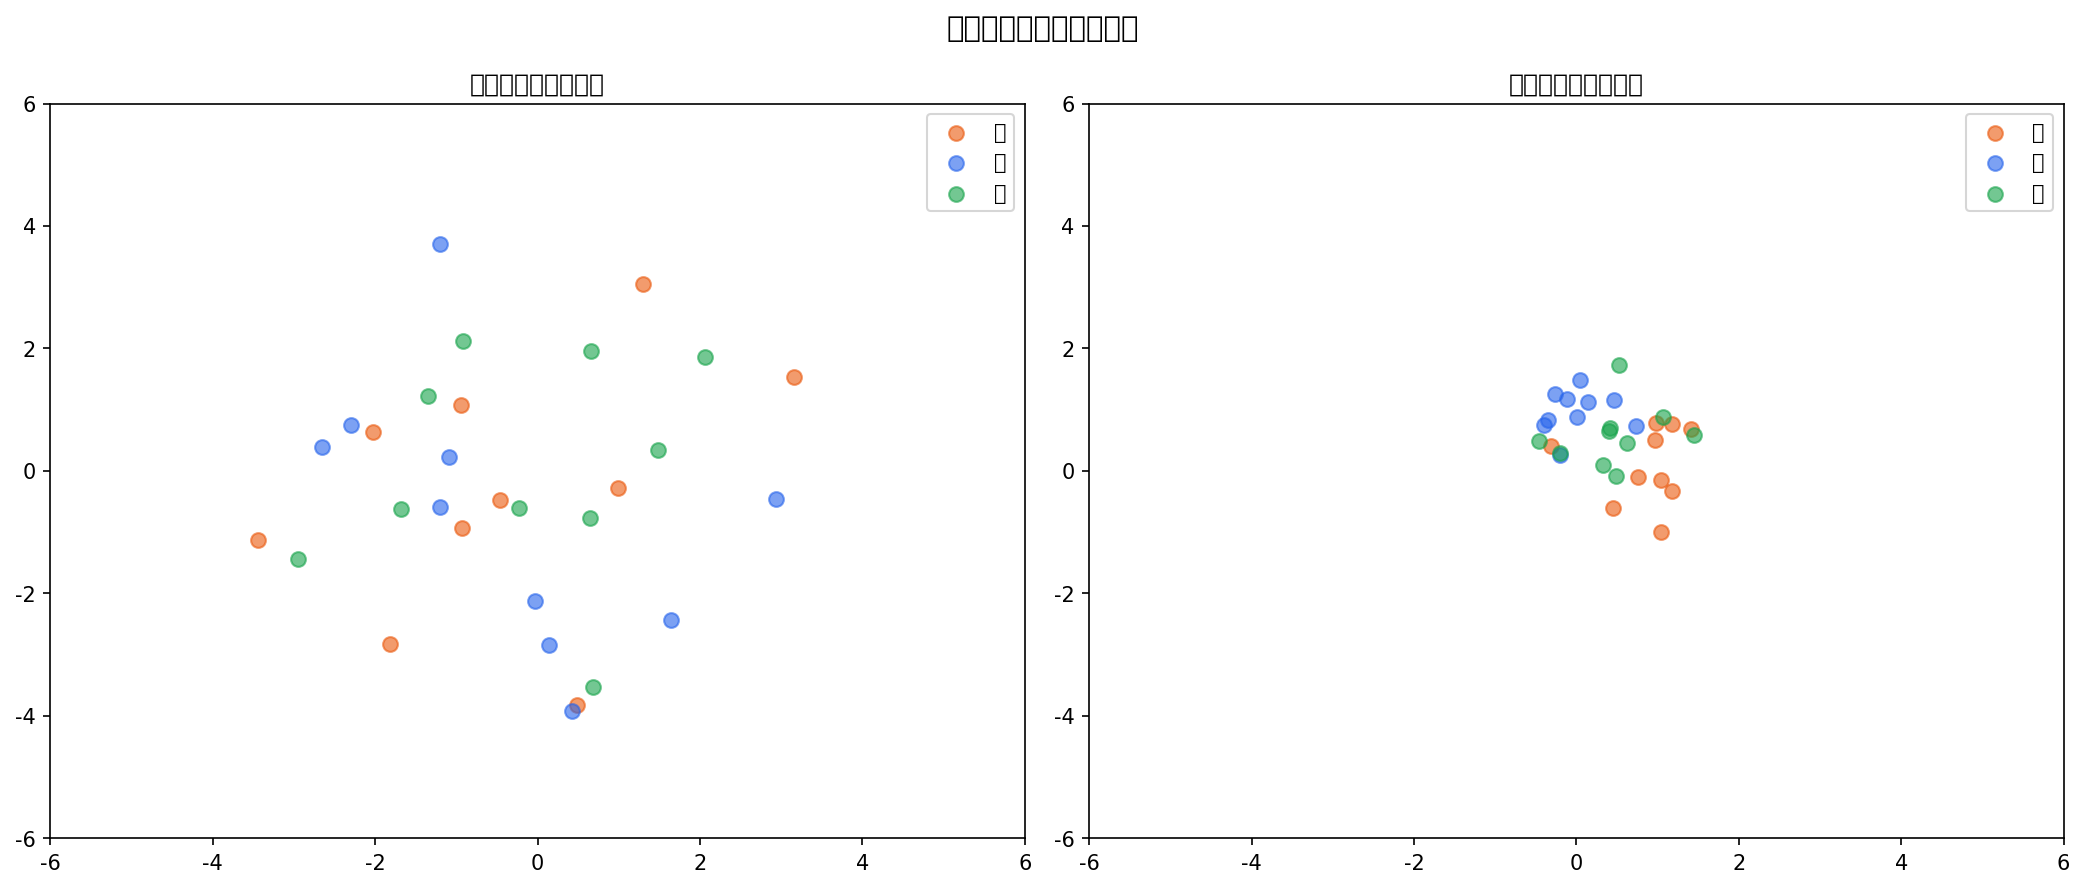

In [5]:
# 模拟对比学习训练过程
# 生成特征空间：3个类别，每类有锚点和正样本
classes = ['猫', '狗', '鸟']
anchors = np.array([[1, 0], [0, 1], [0.5, 0.5]])

# 训练过程：正样本拉近、负样本推远
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 训练前（随机特征）
np.random.seed(42)
before = np.random.randn(30, 2) * 2
labels = np.repeat([0, 1, 2], 10)
colors = ['#ea580c', '#2563eb', '#16a34a']
for c in range(3):
    axes[0].scatter(before[labels==c, 0], before[labels==c, 1], c=colors[c], label=classes[c], alpha=0.6, s=50)
axes[0].set_title('训练前（随机特征）')
axes[0].legend()
axes[0].set_xlim(-6, 6)
axes[0].set_ylim(-6, 6)

# 训练后（聚类）
for c in range(3):
    cluster = np.random.randn(10, 2) * 0.5 + anchors[c]
    axes[1].scatter(cluster[:, 0], cluster[:, 1], c=colors[c], label=classes[c], alpha=0.6, s=50)
axes[1].set_title('训练后（对比学习）')
axes[1].legend()
axes[1].set_xlim(-6, 6)
axes[1].set_ylim(-6, 6)

plt.suptitle('对比学习：特征空间变化', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-12-ssl/contrastive_learning.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. DINO 与 CLIP

### DINO (Self-Distillation)

DINO 使用师生网络，无需负样本：
- 学生网络学习匹配教师网络的输出分布
- 教师网络用 EMA 更新
- 用 Centering + Sharpening 防止坍缩

[[Caron et al., 2021]](https://arxiv.org/abs/2104.14294) DINO 论文

### CLIP (Contrastive Language-Image Pre-training)

CLIP 联合训练图像编码器和文本编码器：
- 图文对 $(I_i, T_i)$ 为正样本
- 不同图文对为负样本
- 学习对齐的图文特征空间

[[Radford et al., 2021]](https://arxiv.org/abs/2103.00020) CLIP 论文

### 比较

| 方法 | 监督信号 | 需负样本 | 核心创新 |
|------|---------|---------|---------|
| SimCLR | 对比 | 是 | 大 batch + 强增强 |
| BYOL | 预测 | 否 | Predictor + EMA |
| DINO | 自蒸馏 | 否 | Centering + Sharpening |
| CLIP | 图文对比 | 是 | 跨模态对齐 |
| MAE | 重建 | 否 | 高比例遮罩重建 |

## 作业

### 作业 1：实现 SimCLR 数据增强

SimCLR 的成功关键在于强数据增强。实现以下增强组合：

In [8]:
# 作业 1：实现 SimCLR 增强管道
def simclr_augment(image):
    """SimCLR 数据增强
    1. 随机裁剪 + 调整大小
    2. 随机颜色抖动
    3. 随机高斯模糊
    """
    # 在此实现
    pass

# 测试
img = np.random.rand(32, 32, 3)
aug1 = simclr_augment(img.copy())
aug2 = simclr_augment(img.copy())
assert aug1.shape == aug2.shape == img.shape
print("作业 1 通过!")

AttributeError: 'NoneType' object has no attribute 'shape'

## 参考文献

1. **Self-Supervised Learning Blog** - Lilian Weng. [lilianweng.github.io](https://lilianweng.github.io/lil-log/2019/11/10/self-supervised-learning.html)
2. **DINO: Emerging Properties in Self-Supervised ViTs** - Caron et al., 2021. [arXiv:2104.14294](https://arxiv.org/abs/2104.14294)
3. **CLIP: Learning Transferable Visual Models** - Radford et al., 2021. [arXiv:2103.00020](https://arxiv.org/abs/2103.00020)
4. **SimCLR: A Simple Framework for Contrastive Learning** - Chen et al., 2020. [arXiv:2002.05709](https://arxiv.org/abs/2002.05709)
5. **MAE: Masked Autoencoders** - He et al., 2021. [arXiv:2111.06377](https://arxiv.org/abs/2111.06377)

---

> 本节内容参考 [Stanford CS231n Lecture 12](https://cs231n.stanford.edu/)